# Logarithmic-barrier central path for a transportation LP

This notebook generates `fig:kantorovich-log-barrier-lp-geometry`. It illustrates the standard interior-point barrier
$$
    p \mapsto \langle c,p
angle - \epsilon\sum_i \log p_i,
    \qquad p\in\Delta_2,
$$
on the same isotropic triangular simplex used in the entropic-regularization path figure. The barrier strength $\epsilon$ is decreased along the central path, so the minimizer moves from the analytic center toward the linear-program optimum. This contrasts with entropic OT/Sinkhorn, where the temperature $\epsilon$ usually defines the regularized problem being solved rather than only an algorithmic path toward the original LP.


In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Polygon

from figure_style import (
    DIRAC_MARKER_SIZE,
    GRAY,
    LIGHT_GRAY,
    ORANGE,
    VIOLET,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

fig_name = "kantorovich-log-barrier-lp-geometry"
out = figure_dir(fig_name)
repo_root = out.parents[2]
thumb_dir = repo_root / "notebooks-figures" / "thumbnails"
thumb_dir.mkdir(parents=True, exist_ok=True)

CMAP = LinearSegmentedColormap.from_list(
    "ot4ml_log_barrier", ["#fff7e6", "#fdd9a8", "#c99ac7", "#5b2c83"]
)

# Use the same equilateral simplex as the entropic-regularization path figure.
vertices = np.array([[0.0, 0.0], [1.0, 0.0], [0.5, np.sqrt(3) / 2]])
cost = np.array([0.0, 0.58, 1.15])
lp_vertex = vertices[int(np.argmin(cost))]


def bary_to_xy(p):
    return np.asarray(p) @ vertices


def log_barrier_objective(p, epsilon, *, display_floor=2e-4):
    p = np.asarray(p)
    # The true logarithmic barrier is infinite on the boundary. For contour
    # rendering only, clamp barycentric coordinates just inside the simplex.
    p_display = np.maximum(p, display_floor)
    return p @ cost - epsilon * np.sum(np.log(p_display), axis=-1)


def central_barycentric(epsilon):
    """Exact KKT solve for min c.p - eps sum_i log(p_i), p in the simplex."""
    epsilon = float(epsilon)
    lo = -float(cost.min()) + 1e-13
    hi = lo + 1.0

    def total(lam):
        return float(np.sum(epsilon / (cost + lam)))

    while total(hi) > 1.0:
        hi = 2.0 * hi + 1.0
    for _ in range(120):
        mid = 0.5 * (lo + hi)
        if total(mid) > 1.0:
            lo = mid
        else:
            hi = mid
    lam = 0.5 * (lo + hi)
    pstar = epsilon / (cost + lam)
    return pstar / pstar.sum()


def objective_levels(values, n=9):
    finite = values[np.isfinite(values)]
    lo, hi = np.nanpercentile(finite, [4, 93])
    if hi <= lo:
        hi = lo + 1.0
    return np.linspace(lo, hi, n)


def color_levels(values, n=46):
    """Local robust color scale for one panel.

    The barrier explodes near the simplex boundary.  Using the raw maximum
    spends most of the colormap on a very thin boundary layer, so each panel
    clips only the upper tail and remaps its own useful range to the full
    palette.
    """
    finite = values[np.isfinite(values)]
    lo = float(np.nanmin(finite))
    hi = float(np.nanpercentile(finite, 88))
    if hi <= lo:
        hi = lo + 1.0
    return np.linspace(lo, hi, n)


resolution = 125
bary = []
for i in range(resolution + 1):
    for j in range(resolution + 1 - i):
        bary.append(np.array([i, j, resolution - i - j], dtype=float) / resolution)
bary = np.asarray(bary)
points = bary_to_xy(bary)

# The chosen range makes the large-epsilon point central and the small-epsilon
# point visibly close to the true LP optimum at the low-cost vertex.
epsilons = [(1.20, "barrier-large.pdf"), (0.18, "barrier-medium.pdf"), (0.022, "barrier-small.pdf")]
path_eps = np.geomspace(1.6, 0.012, 90)
path = np.array([central_barycentric(eps) for eps in path_eps])
path_xy = bary_to_xy(path)


def draw_panel_on_ax(ax, epsilon, *, show_path=False):
    values = log_barrier_objective(bary, epsilon)
    center_xy = bary_to_xy(central_barycentric(epsilon))

    levels = color_levels(values)
    ax.tricontourf(points[:, 0], points[:, 1], values, levels=levels, cmap=CMAP, extend="max", zorder=1)
    ax.tricontour(points[:, 0], points[:, 1], values, levels=objective_levels(values), colors="#5b4a42", linewidths=0.34, alpha=0.46, zorder=2)
    ax.add_patch(Polygon(vertices, closed=True, facecolor="none", edgecolor=GRAY, linewidth=0.86, zorder=4))

    # Linear-program optimum and barrier minimizer/path.
    ax.scatter([lp_vertex[0]], [lp_vertex[1]], s=DIRAC_MARKER_SIZE * 1.10, marker="o", color="#222222", edgecolor="white", linewidth=0.25, zorder=7)
    if show_path:
        colors = [interp_color(t, ORANGE, VIOLET) for t in np.linspace(0, 1, len(path_xy))]
        ax.plot(path_xy[:, 0], path_xy[:, 1], color=VIOLET, linewidth=1.08, alpha=0.86, zorder=5)
        ax.scatter(path_xy[:, 0], path_xy[:, 1], s=DIRAC_MARKER_SIZE * 0.46, marker="o", color=colors, edgecolor="none", zorder=6)
        ax.scatter([path_xy[-1, 0]], [path_xy[-1, 1]], s=DIRAC_MARKER_SIZE * 0.95, marker="o", color=VIOLET, edgecolor="none", zorder=8)
    else:
        ax.scatter([center_xy[0]], [center_xy[1]], s=DIRAC_MARKER_SIZE * 1.12, marker="o", color=VIOLET, edgecolor="none", zorder=8)

    ax.scatter(vertices[:, 0], vertices[:, 1], s=DIRAC_MARKER_SIZE * 0.55, marker="o", color=LIGHT_GRAY, edgecolor="none", zorder=3)
    ax.set_aspect("equal")
    ax.set_xlim(-0.075, 1.075)
    ax.set_ylim(-0.065, np.sqrt(3) / 2 + 0.075)
    remove_axes(ax)


def draw_panel(epsilon, filename, *, show_path=False):
    fig, ax = plt.subplots(figsize=(2.05, 1.78))
    draw_panel_on_ax(ax, epsilon, show_path=show_path)
    save_pdf(fig, out / filename, pad_inches=0.018)
    plt.close(fig)


for eps, filename in epsilons:
    draw_panel(eps, filename)
draw_panel(0.022, "barrier-path.pdf", show_path=True)

# Small contact-sheet thumbnail used by notebooks-figures/README.md and by the
# notebook preview cell below.
thumb_fig, axes = plt.subplots(1, 4, figsize=(6.2, 1.55))
for ax, (eps, _) in zip(axes[:3], epsilons):
    draw_panel_on_ax(ax, eps)
draw_panel_on_ax(axes[3], 0.022, show_path=True)
thumb_fig.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.01, wspace=0.02)
thumb_fig.savefig(thumb_dir / f"{fig_name}.png", dpi=180, bbox_inches="tight", pad_inches=0.02)
plt.close(thumb_fig)


## Figure preview

The output below embeds the current generated thumbnail so the figure renders directly on GitHub.


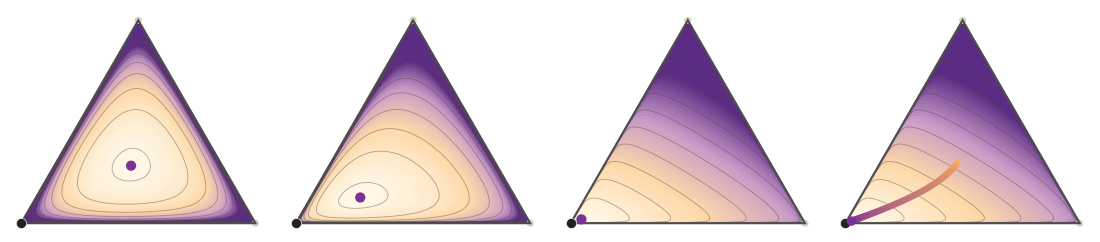

In [2]:
from pathlib import Path
from IPython.display import Image, display
_thumb = Path("thumbnails/kantorovich-log-barrier-lp-geometry.png")
if not _thumb.exists():
    _thumb = Path("notebooks-figures/thumbnails/kantorovich-log-barrier-lp-geometry.png")
display(Image(filename=str(_thumb)))
